### Section 3: Measures of Position (Relative Standing)

While central tendency gives the middle and dispersion measures the spread, **measures of position** describe where a specific data point or value stands relative to the rest of the distribution.

Below are clear, naive examples covering the core measures of position, complete with mathematical formulas, notation pronunciations, and Python implementation comparisons across **Plain Python**, **Standard Library `statistics`**, and **`NumPy`** / **`SciPy`** / **`Matplotlib`**.

In [8]:
import statistics
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

--- 
## 1. Percentiles (Division into 100 Equal Parts)

* **What it does:** Identifies the value below which a given percentage $p\%$ of observations fall.
* **Mathematical Notation:**
  $$P_p = x_{(k)}, \quad \text{where } k = \frac{p}{100} \times (n + 1)$$
  *Where:*
  * $P_p$ (*P sub p*): p-th percentile value
  * $p$ (*p*): Target percentile rank (e.g., 90 for 90th percentile)
  * $n$ (*n*): Sample size
  * $x_{(k)}$ (*x sub k*): Interpolated position in sorted data
* **Naive Example:** Exam scores: `[40, 50, 60, 70, 80, 85, 90, 95, 98, 100]` ($n = 10$). To find the 80th percentile ($P_{80}$):
  $$P_{80} = 95\text{ marks (80\% of students scored at or below 95)}$$
* **When to use:** Standardized testing (SAT/GRE), growth charts, and latency metrics (e.g., p95 / p99 response times).

#### Setup

In [4]:

# 1. Percentile Example (80th Percentile)
scores = [40, 50, 60, 70, 80, 85, 90, 95, 98, 100]
p = 80

# Plain Python (Nearest-rank / Interpolation method)
sorted_scores = sorted(scores)
idx = int(np.ceil((p / 100) * len(sorted_scores))) - 1
p80_python = sorted_scores[idx]

# Standard Library (statistics.quantiles - divides into 100 intervals)
# Note: quantiles returns 99 cut points for percentiles
p80_stats = statistics.quantiles(scores, n=100)[79]

# NumPy Library (np.percentile)
p80_np = np.percentile(scores, p)

# SciPy Library (stats.scoreatpercentile)
p80_scipy = stats.scoreatpercentile(scores, p)

print(f"Plain Python (Nearest Rank):  {p80_python}")
print(f"statistics.quantiles(n=100): {p80_stats:.2f}")
print(f"np.percentile():             {p80_np:.2f}")
print(f"scipy scoreatpercentile():   {p80_scipy:.2f}")

Plain Python (Nearest Rank):  95
statistics.quantiles(n=100): 97.40
np.percentile():             95.60
scipy scoreatpercentile():   95.60


--- 
## 2. Quartiles & Interquartile Range (Division into 4 Equal Parts)

* **What it does:** Splits sorted data into four quarters: $Q_1$ (25th percentile), $Q_2$ (50th percentile / Median), and $Q_3$ (75th percentile).
* **Mathematical Notation:**
  $$Q_1 = P_{25}, \quad Q_2 = P_{50} = \text{Median}, \quad Q_3 = P_{75}$$
  *Where:*
  * $Q_1$ (*Q one*): First quartile (lower 25% boundary)
  * $Q_2$ (*Q two*): Second quartile (median cut point)
  * $Q_3$ (*Q three*): Third quartile (upper 25% boundary)
* **Naive Example:** Daily steps in thousands: `[2, 4, 6, 8, 10, 12, 14]` ($n = 7$).
  $$Q_1 = 4, \quad Q_2 = 8, \quad Q_3 = 12$$
* **When to use:** Box plot summaries, outlier detection rules, and quartile distribution binning.

--- Standard Library (statistics.quantiles) ---
Q1: 4.0, Q2 (Median): 8.0, Q3: 12.0

--- NumPy Library (np.percentile) ---
Q1: 5.0, Q2 (Median): 8.0, Q3: 11.0


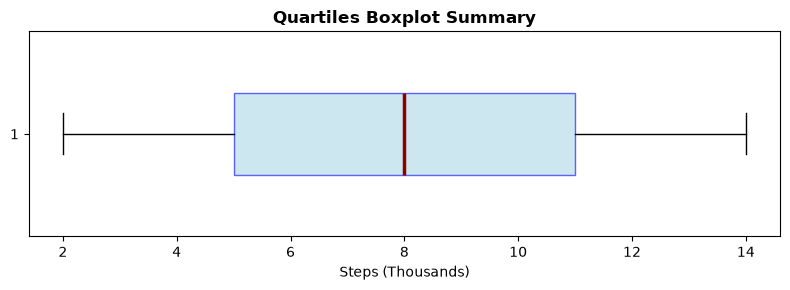

In [ ]:
# 2. Quartiles Example
steps = [2, 4, 6, 8, 10, 12, 14]
# Standard Library (statistics.quantiles - splits into 4 parts: Q1, Q2, Q3)
q1_stats, q2_stats, q3_stats = statistics.quantiles(steps, n=4)
# NumPy Library
q1_np, q2_np, q3_np = np.percentile(steps, [25, 50, 75])

print("--- Standard Library (statistics.quantiles) ---")
print(f"Q1: {q1_stats:.1f}, Q2 (Median): {q2_stats:.1f}, Q3: {q3_stats:.1f}")

print("\n--- NumPy Library (np.percentile) ---")
print(f"Q1: {q1_np:.1f}, Q2 (Median): {q2_np:.1f}, Q3: {q3_np:.1f}")
# Visualization using horizontal Boxplot (using non-deprecated orientation parameter)
fig, ax = plt.subplots(figsize=(8, 3))
bp = ax.boxplot(steps, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))
ax.set_title("Quartiles Boxplot Summary", fontweight='bold')
ax.set_xlabel("Steps (Thousands)")
plt.tight_layout()
plt.show()

--- 
#### 3. Z-Score / Standard Score (Distance from Mean in Std Devs)

* **What it does:** Measures how many standard deviations a raw score $x$ lies above or below the sample mean.
* **Mathematical Notation:**
  $$z = \frac{x - \bar{x}}{s}$$
  *Where:*
  * $z$ (*z-score*): Standardized relative position score
  * $x$ (*x*): Individual data point
  * $\bar{x}$ (*x-bar*): Sample mean
  * $s$ (*s*): Sample standard deviation
* **Naive Example:** An exam score of $x = 85$ in a class where $\bar{x} = 70$ and $s = 10$:
  $$z = \frac{85 - 70}{10} = \frac{15}{10} = +1.50$$
  *(The score is 1.5 standard deviations above the average class performance)*.
* **When to use:** Machine learning feature scaling (StandardScaler), anomaly/outlier detection ($\vert{}z\vert{} > 3$), and cross-group metric comparisons.

In [9]:
# 3. Z-Score Example
data = [50, 60, 70, 80, 90]
target_val = 85

# Plain Python
mean_val = sum(data) / len(data)
std_val = math.sqrt(sum((x - mean_val) ** 2 for x in data) / (len(data) - 1))
z_python = (target_val - mean_val) / std_val

# SciPy Library (Calculates Z-scores for all elements in array)
# ddof=1 ensures sample standard deviation in denominator
z_array_scipy = stats.zscore(data + [target_val], ddof=1)
z_target_scipy = z_array_scipy[-1]

# NumPy Vectorized Transformation for Entire Dataset
np_data = np.array(data)
z_all_np = (np_data - np.mean(np_data)) / np.std(np_data, ddof=1)

print(f"Plain Python Z-Score for x=85:       {z_python:+.3f}")
print(f"SciPy stats.zscore for x=85:         {z_target_scipy:+.3f}")
print(f"NumPy Z-scores for full dataset:   {np.round(z_all_np, 2)}")


Plain Python Z-Score for x=85:       +0.949
SciPy stats.zscore for x=85:         +0.811
NumPy Z-scores for full dataset:   [-1.26 -0.63  0.    0.63  1.26]


#### Z-Score (Standard Score) (Points to Ponder)
A **Z-score** measures how many standard deviations ($\sigma$) a specific data point ($x$) is away from the mean ($\mu$):

$$\text{Z-score} = \frac{x - \mu}{\sigma}$$

---

### What Z-Score Values Mean

| Z-Score | Condition | Interpretation | Location on Bell Curve |
| :--- | :--- | :--- | :--- |
| **Zero ($Z = 0$)** | $x = \mu$ | Data point is **exactly equal to the average** | Dead center |
| **Positive ($Z > 0$)** | $x > \mu$ | Data point is **above/greater than the average** | Right of the center |
| **Negative ($Z < 0$)** | $x < \mu$ | Data point is **below/less than the average** | Left of the center |

---

### Numerical Example

For a test with **Mean ($\mu$) = 70** and **Standard Deviation ($\sigma$) = 10**:

* **Score = 70 ($Z = 0.0$):**
  $$Z = \frac{70 - 70}{10} = \mathbf{0.0} \quad \text{(Exactly at average)}$$

* **Score = 85 ($Z = +1.5$):**
  $$Z = \frac{85 - 70}{10} = \mathbf{+1.5} \quad \text{(1.5 standard deviations above average)}$$

* **Score = 50 ($Z = -2.0$):**
  $$Z = \frac{50 - 70}{10} = \mathbf{-2.0} \quad \text{(2.0 standard deviations below average)}$$

---

### Context Matters for Negative Z-Scores

* **Negative is Desirable:** Software latency, hospital wait times, race completion times, golf scores.
* **Negative is Undesirable:** Exam scores, sales revenue, battery life, yield rates.

--- 
#### 4. Percentile Rank (Percentage of Scores At or Below a Value)

* **What it does:** Reverses the percentile operation by calculating what percentage of the dataset falls at or below a specific observation value $x$.
* **Mathematical Notation:**
  $$\text{PR} = \left( \frac{c_L + 0.5 f_E}{n} \right) \times 100$$
  *Where:*
  * $\text{PR}$ (*Percentile Rank*): Percentile rank (0% to 100%)
  * $c_L$ (*count lower*): Total number of values strictly less than $x$
  * $f_E$ (*frequency equal*): Total number of values equal to $x$
  * $n$ (*n*): Total observations
* **Naive Example:** Class test scores: `[50, 60, 70, 70, 80, 90]` ($n = 6$). For score $x = 70$ ($c_L = 2$, $f_E = 2$):
  $$\text{PR} = \left( \frac{2 + 0.5(2)}{6} \right) \times 100 = \frac{3}{6} \times 100 = 50\%$$
* **When to use:** Evaluating candidate rankings in hiring tests, clinical evaluations, and competitive sports metrics.

In [ ]:
# 4. Percentile Rank Example
scores = [50, 60, 70, 70, 80, 90]
target_score = 70

# Plain Python
count_less = sum(1 for x in scores if x < target_score)
count_equal = sum(1 for x in scores if x == target_score)
pr_python = ((count_less + 0.5 * count_equal) / len(scores)) * 100

# SciPy Library (stats.percentileofscore)
# kind='weak' counts <= target, kind='rank' uses fractional ranking
pr_scipy_strict = stats.percentileofscore(scores, target_score, kind='strict') # strict counts < target
pr_scipy_mean = stats.percentileofscore(scores, target_score, kind='mean')

print(f"Plain Python Percentile Rank (x=70): {pr_python:.1f}%")
print(f"SciPy percentileofscore (kind='mean'): {pr_scipy_mean:.1f}%")
print(f"SciPy percentileofscore (kind='strict'): {pr_scipy_strict:.1f}%")


Plain Python Percentile Rank (x=70): 50.0%
SciPy percentileofscore (kind='mean'): 50.0%
SciPy percentileofscore (kind='strict'): 33.3%
